# Phase screens simulation

This notebook demonstrates agreement between theoretical weight function computed with `pyweif` and simulations performed by [`aotools`](https://github.com/AOtools/aotools) package. The weight function is a response to single turbulent layer on its altitude, so we simulate light propagation and calculate scintillation numerically for a grid of altitudes.

Note that we utilize `astopy.units` here because `pyweif` and `aotools` use different measurement unit conventions. 

**[Run this NB in Google Colab](https://colab.research.google.com/github/matwey/pyweif/blob/master/docs/notebooks/phase_screens.ipynb)**

## Install and import the required libraries

In [1]:
%pip install pyweif aotools astropy tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pylab as plt

from tqdm.notebook import tqdm

import aotools
from aotools.turbulence.phasescreen import ft_phase_screen
from aotools.functions.pupil import circle
from aotools.opticalpropagation import angularSpectrum

from astropy import units as u

from pyweif import WeightFunction
import pyweif.sf as sf
import pyweif.af as af

## Define simulation parameters

Since `aotools` is not yet able to simulate polychromatic radiation we consider monochromatic case of $550~\text{nm}$ here.
For the aperture we choose the circular aperture of $15~\text{mm}$ diameter which is rougly corresponds to MASS A aperture.

In [3]:
WAVELENGTH  = 550 * u.nm
DIAMETER    = 15 * u.mm

NX_SIZE     = 512
PXL_SCALE   = 0.625 * u.mm
N_SCREENS   = 500

OUTER_SCALE = 50.0 * u.m
INNER_SCALE = 1.0 * u.mm
R0          = 0.5 * u.m

Note, that `aotools` prefers to use Fried radius $r_0$ to quantify optical turbulence power while it is more natural to use refractive index structure constant $C_n^2$ in this notebook. Fortunately, it is easy to convert between this two quantities.

In [4]:
CN2         = aotools.r0_to_cn2(R0.to(u.m).value, lamda=WAVELENGTH.to(u.m).value)

f"Equivalent C_n^2 = {CN2:.3e} m^-2/3"

'Equivalent C_n^2 = 5.751e-14 m^-2/3'

Here we construct the aperture from `aotools` point of view. Since `aotools` is the phase screen simulator we need to define pixel mask for circular aperture.

In [5]:
MASK = circle(radius = DIAMETER / PXL_SCALE / 2, size = NX_SIZE)
EXPECTED_FLUX = np.sum(MASK)

f"Expected flux = {EXPECTED_FLUX:.2f} ADU"

'Expected flux = 448.00 ADU'

In order to save computational resources during simulations we make the following trick here. We sample the turbulent layer and then we change the altitude of the virtual telescope relative to the layer. Then we can integrate over the telescope input pupil to estimate what flux the telescope would measure.

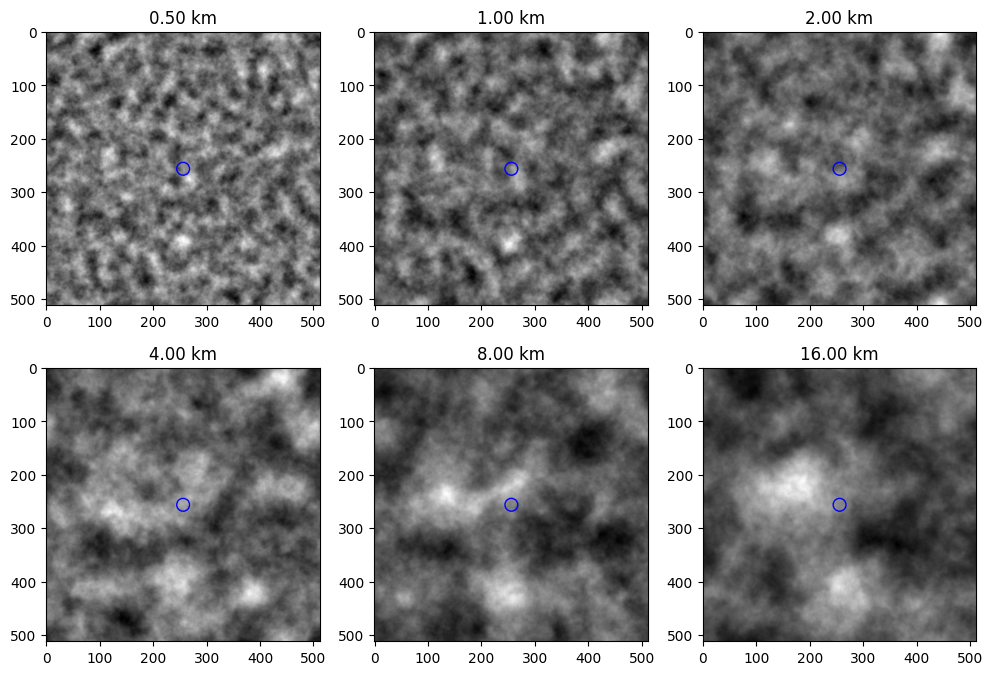

In [6]:
altitudes = np.asarray([0.5, 1.0, 2.0, 4.0, 8.0, 16.0]) * u.km

fig, ax = plt.subplots(2, 3, figsize=(12, 8))

assert altitudes.size == ax.size

phi = ft_phase_screen(R0.to(u.m).value, NX_SIZE,
                      PXL_SCALE.to(u.m).value, OUTER_SCALE.to(u.m).value, INNER_SCALE.to(u.m).value,
                      seed=42)
E = np.exp(1j*phi)
E_prop = E

for i, (dh, h) in enumerate(zip(np.diff(altitudes, prepend=0.0 * u.km), altitudes)):
    row = i // ax.shape[1]
    col = i % ax.shape[1]

    E_prop = angularSpectrum(E_prop, WAVELENGTH.to(u.m).value, PXL_SCALE.to(u.m).value, PXL_SCALE.to(u.m).value, dh.to(u.m).value)

    ax[row, col].imshow(np.abs(E_prop)**2, cmap="gray")
    ax[row, col].set_title(f"{h:.2f}")
    aperture = plt.Circle((NX_SIZE/2, NX_SIZE/2), DIAMETER / PXL_SCALE / 2, color='blue', fill=False)
    ax[row, col].add_artist(aperture)

pass

Then we generate a sample of turbulent layers.

In [7]:
altitudes = np.linspace(0.5, 16.0, 20) * u.km

fluxes = np.empty((altitudes.size, N_SCREENS), dtype=np.float64)
for seed in tqdm(range(N_SCREENS)):
    phi = ft_phase_screen(R0.to(u.m).value, NX_SIZE,
                          PXL_SCALE.to(u.m).value, OUTER_SCALE.to(u.m).value, INNER_SCALE.to(u.m).value,
                          seed=seed)
    E = np.exp(1j*phi)
    E_prop = E

    for i, dh in enumerate(np.diff(altitudes, prepend=0.0 * u.km)):
        E_prop = angularSpectrum(E_prop, WAVELENGTH.to(u.m).value, PXL_SCALE.to(u.m).value, PXL_SCALE.to(u.m).value, dh.to(u.m).value)
        E_prop_masked = np.ma.array(E_prop, mask = ~MASK.astype(bool))
        fluxes[i, seed] = np.sum(np.abs(E_prop_masked)**2)

  0%|          | 0/500 [00:00<?, ?it/s]

Here we calculate scintillation index using the generated sample and the index definition:
$$
s^2 = \left<\left(\frac{I - I_0}{I_0}\right)^2\right>
$$

Dependence of scintillation index $s^2$ of the altitude $z$ is defined by the weight function:
$$
s^2 = C_n^2 W(z)
$$

In [8]:
relative_fluxes = fluxes / EXPECTED_FLUX
scintilation_index = np.var(relative_fluxes, axis=1)
scintilation_index_err = np.sqrt(2*scintilation_index**2/(fluxes.shape[1]-1))
ps_wf = scintilation_index / CN2
ps_wf_err = scintilation_index_err / CN2

Here we just run `pyweif` to calculate theoretical weight function for given aperture and wavelength:

In [9]:
af_circular = af.Circular()
sf_mono = sf.Mono()
wf_point_mono = WeightFunction(sf_mono, WAVELENGTH.to(u.nm).value, af_circular, DIAMETER.to(u.mm).value, 1024)

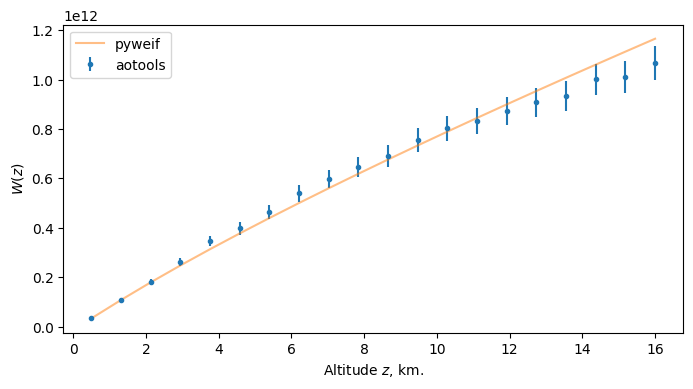

In [10]:
plt.figure(figsize=(8, 4))
plt.errorbar(altitudes.to(u.km), ps_wf, ps_wf_err,
             fmt='.', label="aotools")
plt.plot(altitudes.to(u.km), wf_point_mono(altitudes.to(u.km).value),
         '-', alpha=0.5, label="pyweif")
plt.xlabel("Altitude $z$, km.")
plt.ylabel("$W(z)$")
plt.legend()

pass